# Collection Album: Packs to Complete the Album (Question 4)

Completing the 81-card album is a coupon collector problem. The first cards fall fast, the last few are slow, and the average hides the gap. This notebook is the model behind Question 4. It takes the feature configuration, anchors the mean with a closed form, then simulates 60,000 albums to recover the median, the spread, and the shape of the tail.

The configuration is the one from Question 3. The full editable version, with the per-card drop weights, is in the [configuration sheet](https://docs.google.com/spreadsheets/d/1foRnmhvBxSKDBGWecdrQu3VuKdiemkG_giFvcAoH800/edit?usp=sharing), and an interactive version of this model runs in the [browser simulator](https://taljacob28.github.io/realplay-collection-album-simulator/).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Configuration. These mirror the Parameters tab of the feature config sheet,
# so the model runs on the same knobs described in Question 3.
CONFIG = {
    "sets": 9,            # number of sets in the album
    "cards_per_set": 9,   # cards in each set
    "cards_per_pack": 4,  # cards drawn per pack, duplicates allowed
    "drop_model": "uniform",
}
SEED = 42
N_RUNS = 60_000

n = CONFIG["sets"] * CONFIG["cards_per_set"]   # 81 cards total
cards_per_pack = CONFIG["cards_per_pack"]
probs = np.ones(n) / n                         # uniform baseline; raise a weight to make a card rarer

print(f"cards = {n}   cards_per_pack = {cards_per_pack}   drop_model = {CONFIG['drop_model']}")

cards = 81   cards_per_pack = 4   drop_model = uniform


## Analytic anchor

For a uniform draw, the expected number of single-card draws to collect all `n` cards is `n * H_n`, where `H_n` is the harmonic number. Dividing by four cards per pack gives the expected packs.

In [2]:
H = np.sum(1.0 / np.arange(1, n + 1))
E_draws = n * H
E_packs = E_draws / cards_per_pack
print(f"H_{n}                = {H:.4f}")
print(f"E[draws for all {n}]  = {E_draws:.1f}")
print(f"E[packs] (/ {cards_per_pack})        = {E_packs:.2f}")

H_81                = 4.9778
E[draws for all 81]  = 403.2
E[packs] (/ 4)        = 100.80


## Simulation

The closed form gives only the mean. The simulation gives the full distribution, the percentiles, and the shape of the tail, and it extends to pity and weighted drops where no clean formula exists.

One caution, and it runs against Part 1. There the median sat far below the mean and the gap was the story. Here the two nearly coincide, so the mean is a fair summary of the count. The story is not the spread of the total, it is where the packs fall inside the album, and the total runs high enough to put completion out of reach for most players.

Assumption: each of the four cards in a pack is drawn on its own, so a pack sometimes holds a duplicate. The uniform case uses a fast integer draw, and any weighted table falls back to a probability draw, so one function serves both.

In [3]:
def simulate(probs, n, cards_per_pack, n_runs, seed, max_packs=600, batch=4000):
    rng = np.random.default_rng(seed)
    uniform = np.allclose(probs, probs[0])
    out = np.empty(n_runs, dtype=np.int32)
    pos = 0
    while pos < n_runs:
        b = min(batch, n_runs - pos)
        if uniform:
            draws = rng.integers(0, n, size=(b, max_packs, cards_per_pack))
        else:
            draws = rng.choice(n, size=(b, max_packs, cards_per_pack), p=probs)
        seen = np.zeros((b, n), dtype=bool)
        count = np.zeros(b, dtype=np.int32)
        done = np.zeros(b, dtype=bool)
        times = np.full(b, max_packs, dtype=np.int32)
        rows = np.arange(b)
        for p in range(max_packs):
            for k in range(cards_per_pack):
                col = draws[:, p, k]
                newly = (~seen[rows, col]) & (~done)
                seen[rows, col] = True
                count += newly
            jd = (count == n) & (~done)
            times[jd] = p + 1
            done |= jd
            if done.all():
                break
        out[pos:pos + b] = times
        pos += b
    return out

In [4]:
packs = simulate(probs, n, cards_per_pack, N_RUNS, SEED)
mean_p = packs.mean()
median_p = int(np.median(packs))
p90, p99 = np.percentile(packs, [90, 99])
print(f"runs   = {N_RUNS:,}")
print(f"mean   = {mean_p:.1f} packs")
print(f"median = {median_p} packs")
print(f"p90    = {p90:.0f} packs")
print(f"p99    = {p99:.0f} packs")
print(f"max    = {packs.max()} packs")
print(f"mean - median gap = {mean_p - median_p:.1f} packs (tight, unlike Part 1)")

runs   = 60,000
mean   = 101.2 packs
median = 97 packs
p90    = 134 packs
p99    = 182 packs
max    = 305 packs
mean - median gap = 4.2 packs (tight, unlike Part 1)


## Analytic against simulation

The two agree. The small gap is whole-pack rounding, the simulation counts full packs while the closed form divides draws by four.

In [5]:
print(f"analytic mean : {E_packs:.2f} packs")
print(f"sim mean      : {mean_p:.2f} packs")
print(f"gap           : {mean_p - E_packs:+.2f} packs (whole-pack rounding)")

analytic mean : 100.80 packs
sim mean      : 101.22 packs
gap           : +0.42 packs (whole-pack rounding)


## The tail

Splitting the packs by how far the album is already filled shows where the cost sits. The first half of the album is nearly free. The last ten cards carry most of the weight, and the final card alone is a fifth of the whole run. This is the stall point, and the place to watch for churn.

In [6]:
packs_per_step = np.array([n / (n - k) for k in range(n)]) / cards_per_pack
cum = np.cumsum(packs_per_step)

first_half = packs_per_step[: n // 2].sum()
last10 = packs_per_step[-10:].sum()
last1 = packs_per_step[-1]
print(f"first {n // 2} cards : {first_half:5.1f} packs  ({100 * first_half / E_packs:2.0f}%)")
print(f"last 10 cards : {last10:5.1f} packs  ({100 * last10 / E_packs:2.0f}%)")
print(f"last card     : {last1:5.1f} packs  ({100 * last1 / E_packs:2.0f}%)")

first 40 cards :  13.7 packs  (14%)
last 10 cards :  59.3 packs  (59%)
last card     :  20.2 packs  (20%)


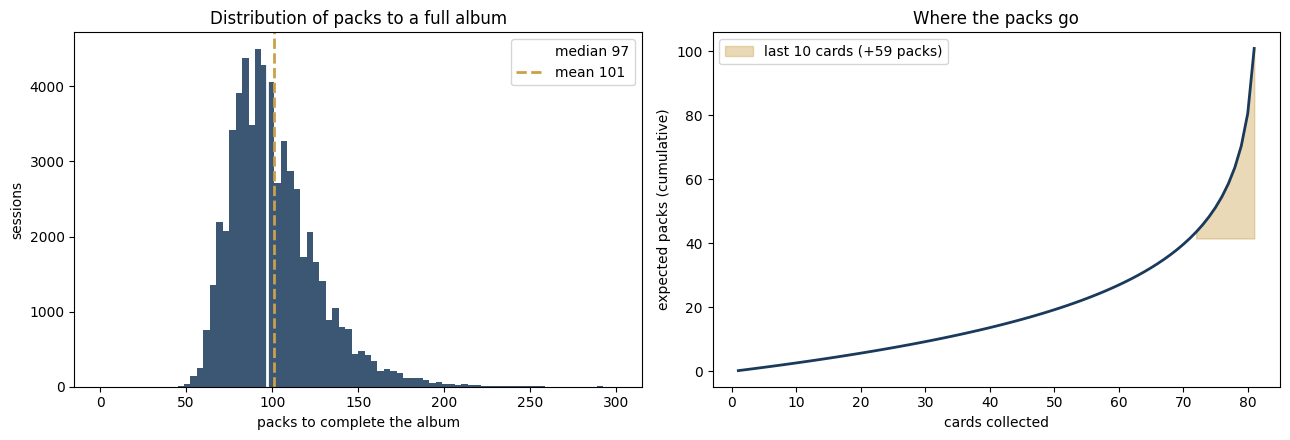

In [7]:
NAVY, GOLD = "#1A3A5C", "#C9A14A"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.hist(packs, bins=80, range=(0, 300), color=NAVY, alpha=0.85)
ax1.axvline(median_p, color="white", lw=2, label=f"median {median_p}")
ax1.axvline(mean_p, color=GOLD, lw=2, ls="--", label=f"mean {mean_p:.0f}")
ax1.set_xlabel("packs to complete the album")
ax1.set_ylabel("sessions")
ax1.set_title("Distribution of packs to a full album")
ax1.legend()

base = cum[n - 11]                       # packs after the first 71 cards
x = np.arange(1, n + 1)
ax2.plot(x, cum, color=NAVY, lw=2)
ax2.fill_between(np.arange(n - 9, n + 1), base, cum[n - 10:], color=GOLD, alpha=0.4,
                 label=f"last 10 cards (+{cum[-1] - base:.0f} packs)")
ax2.set_xlabel("cards collected")
ax2.set_ylabel("expected packs (cumulative)")
ax2.set_title("Where the packs go")
ax2.legend()

plt.tight_layout()
plt.show()

## Findings

A full album costs about 101 packs on average. The median is 97, close to the mean, so the count itself is concentrated. This is not Part 1, where the median was the hidden story. Here the count is steady, and the headline fact is the size of it. Completion is a long way off, and most players never reach it.

The tail is the real story. The first half of the album takes about 14 percent of the packs. The last ten cards take about 59 percent. The final card alone takes about 20 percent. A player who has filled most of the album still faces the longest stretch, and this is where the chase turns into a grind.

Two things follow. Completion is rare, so the feature lives in the journey, not the finish line. Set rewards along the way, near-completion on a single set, and useful duplicates are what hold the player, not the full-album reward most will never see. And completion rate is the wrong KPI. Set completion and progression measure what happens.

This is the uniform baseline. Pity, a targeted offer for a missing card, or trading all attack the same tail, and each one is testable against it.